## Feature Engineering

## Data Importing 
King County House Price Prediction Dataset

In [9]:
import pandas as pd
house_price_data=pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/kc_house_data/kc_house_data.csv")

house_price_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  int64  
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [10]:
house_price_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,6762700020,20141013T000000,7700000,6,8.00,12050,27600,2.5,0,3,...,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
1,9808700762,20140611T000000,7062500,5,4.50,10040,37325,2.0,1,2,...,11,7680,2360,1940,2001,98004,47.6500,-122.214,3930,25449
2,9208900037,20140919T000000,6885000,6,7.75,9890,31374,2.0,0,4,...,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
3,2470100110,20140804T000000,5570000,5,5.75,9200,35069,2.0,0,0,...,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
4,8907500070,20150413T000000,5350000,5,5.00,8000,23985,2.0,0,4,...,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750


1. Print columns names
2. prepare the train and test data

In [3]:
house_price_data.columns.values

<StringArray>
[           'id',          'date',         'price',      'bedrooms',
     'bathrooms',   'sqft_living',      'sqft_lot',        'floors',
    'waterfront',          'view',     'condition',         'grade',
    'sqft_above', 'sqft_basement',      'yr_built',  'yr_renovated',
       'zipcode',           'lat',          'long', 'sqft_living15',
    'sqft_lot15']
Length: 21, dtype: str

In [4]:
pred_cols=house_price_data.columns.values[3:]
print(pred_cols)

<StringArray>
[     'bedrooms',     'bathrooms',   'sqft_living',      'sqft_lot',
        'floors',    'waterfront',          'view',     'condition',
         'grade',    'sqft_above', 'sqft_basement',      'yr_built',
  'yr_renovated',       'zipcode',           'lat',          'long',
 'sqft_living15',    'sqft_lot15']
Length: 18, dtype: str


In [5]:
X = house_price_data[pred_cols]
y = house_price_data['price']

from sklearn import model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y ,train_size=0.8, random_state=55)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(17290, 18)
(17290,)
(4323, 18)
(4323,)


## Basic Model

### Model1 with all numerical columns

In [6]:
from  sklearn.linear_model import LinearRegression
model1 = LinearRegression()
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
#Rsquared value on train and test data
from sklearn import metrics
y_pred_train=model1.predict(X_train)
print("Train RSquared", metrics.r2_score(y_train,y_pred_train))

y_pred_test=model1.predict(X_test)
print("Test RSquared",metrics.r2_score(y_test,y_pred_test))

import numpy as np
#MAPE
print("MAPE on Train data : ", round(np.mean(np.abs(y_train - y_pred_train)/y_train),2))
print("MAPE on Test data : ", round(np.mean(np.abs(y_test - y_pred_test)/y_test),2))

Train RSquared 0.7004310823997753
Test RSquared 0.6964362880041145
MAPE on Train data :  0.26
MAPE on Test data :  0.26


## Handling Date variables

In [14]:
date_vars = ['date', 'yr_built', 'yr_renovated']
house_price_dates=house_price_data[date_vars].copy()
house_price_dates.head()

,date,yr_built,yr_renovated
0,20141013T000000,1910,1987
1,20140611T000000,1940,2001
2,20140919T000000,2001,0
3,20140804T000000,2001,0
4,20150413T000000,2009,0


In [15]:
house_price_dates['sale_year'] = np.int64([d[0:4] for d in house_price_dates["date"]])
house_price_dates['sale_month'] = np.int64([d[4:6] for d in house_price_dates["date"]])
house_price_dates['day_sold'] = np.int64([d[6:8] for d in house_price_dates["date"]])
house_price_dates['age_of_house'] = house_price_dates['sale_year'] - house_price_dates['yr_built']
house_price_dates['Ind_renovated'] = house_price_dates['yr_renovated']>0     # Renovation indicator var: True if renovated(yr_renovated != 0) else False
house_price_dates.head()

,date,yr_built,yr_renovated,sale_year,sale_month,day_sold,age_of_house,Ind_renovated
0,20141013T000000,1910,1987,2014,10,13,104,True
1,20140611T000000,1940,2001,2014,6,11,74,True
2,20140919T000000,2001,0,2014,9,19,13,False
3,20140804T000000,2001,0,2014,8,4,13,False
4,20150413T000000,2009,0,2015,4,13,6,False


In [16]:
house_price_dates1=house_price_dates.drop(date_vars, axis=1) #keep only newly derived variables
house_price_data_dates=house_price_data.join(house_price_dates1)
house_price_data_dates.shape

(21613, 26)

In [17]:
house_price_data_dates.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,day_sold,age_of_house,Ind_renovated
0,6762700020,20141013T000000,7700000,6,8.00,12050,27600,2.5,0,3,...,98102,47.6298,-122.323,3940,8800,2014,10,13,104,True
1,9808700762,20140611T000000,7062500,5,4.50,10040,37325,2.0,1,2,...,98004,47.6500,-122.214,3930,25449,2014,6,11,74,True
2,9208900037,20140919T000000,6885000,6,7.75,9890,31374,2.0,0,4,...,98039,47.6305,-122.240,4540,42730,2014,9,19,13,False
3,2470100110,20140804T000000,5570000,5,5.75,9200,35069,2.0,0,0,...,98039,47.6289,-122.233,3560,24345,2014,8,4,13,False
4,8907500070,20150413T000000,5350000,5,5.00,8000,23985,2.0,0,4,...,98004,47.6232,-122.220,4600,21750,2015,4,13,6,False


### Model2 with Date columns

In [18]:
col_names = house_price_data_dates.columns.values
#print(col_names)

x_col_names=col_names[3:]
print(x_col_names)

X = house_price_data_dates[x_col_names]
y = house_price_data_dates['price']

from sklearn  import model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y ,test_size=0.2, random_state=55)


print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

<StringArray>
[     'bedrooms',     'bathrooms',   'sqft_living',      'sqft_lot',
        'floors',    'waterfront',          'view',     'condition',
         'grade',    'sqft_above', 'sqft_basement',      'yr_built',
  'yr_renovated',       'zipcode',           'lat',          'long',
 'sqft_living15',    'sqft_lot15',     'sale_year',    'sale_month',
      'day_sold',  'age_of_house', 'Ind_renovated']
Length: 23, dtype: str
(17290, 23)
(17290,)
(4323, 23)
(4323,)


In [19]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Rsquared Calculation on Train data
y_pred_train=model2.predict(X_train)
print("Train data R-Squared : ", metrics.r2_score(y_train,y_pred_train))

#Rsquared Calculation on test data
y_pred_test=model2.predict(X_test)
print("Test data R-Squared : " , metrics.r2_score(y_test,y_pred_test))

#MAPE
print("MAPE on Train data : ", round(np.mean(np.abs(y_train - y_pred_train)/y_train),2))
print("MAPE on Test data : ", round(np.mean(np.abs(y_test - y_pred_test)/y_test),2))

# The result is same as previous model without newly extracted date features because it depends on feature's predictive power and not just on number of features.

Train data R-Squared :  0.7031095708216483
Test data R-Squared :  0.6984175384447163
MAPE on Train data :  0.26
MAPE on Test data :  0.26


## Handling Geo location(Lat-Long) Variables

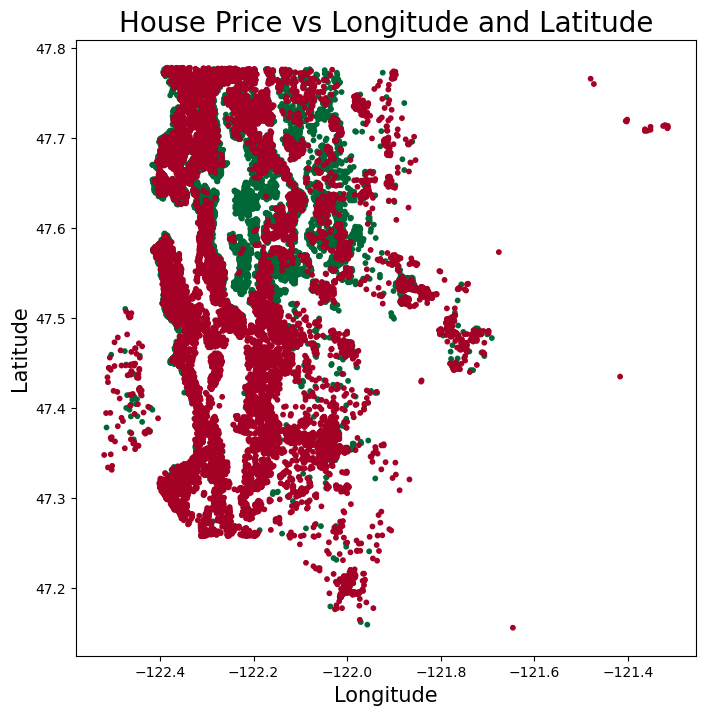

In [ ]:
# House Price vs Longitude and Latitude
bubble_col= house_price_data["price"] > house_price_data["price"].quantile(0.7)  # Top 30% priced houses are represented in green color and rest in red color

import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.scatter(house_price_data["long"],house_price_data["lat"], c=bubble_col,cmap="RdYlGn",s=10)
plt.title('House Price vs Longitude and Latitude', fontsize=20)
plt.xlabel('Longitude', fontsize=15)
plt.ylabel('Latitude', fontsize=15)
plt.show()

### High price houses center

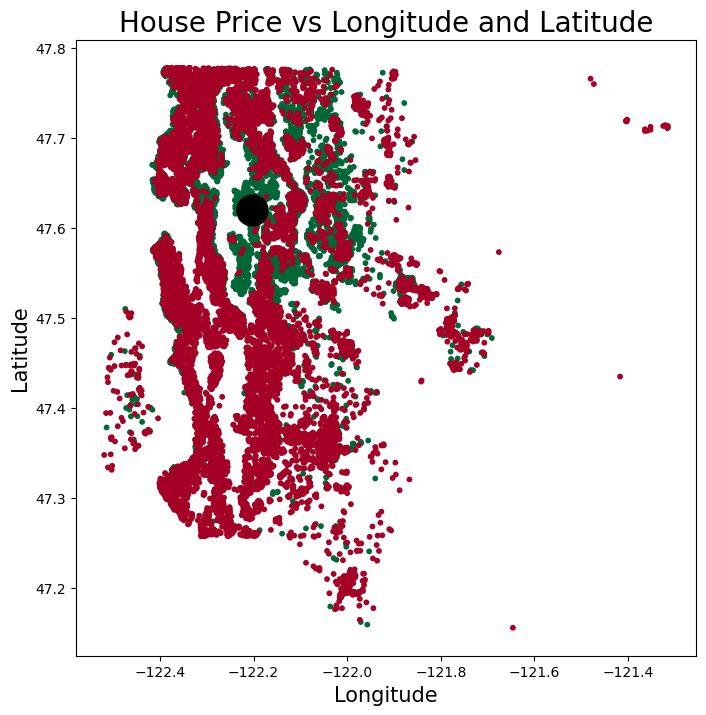

In [ ]:
# Center of high priced houses(green colored points)
high_long_mean=house_price_data["long"][bubble_col].mean()
high_lat_mean=house_price_data["lat"][bubble_col].mean()

plt.figure(figsize=(8,8))
plt.scatter(house_price_data["long"],house_price_data["lat"], c=bubble_col,cmap="RdYlGn",s=10)
plt.scatter(high_long_mean,high_lat_mean, c="black", s=500)  # Black dot represents center of high priced houses

plt.title('House Price vs Longitude and Latitude', fontsize=20)
plt.xlabel('Longitude', fontsize=15)
plt.ylabel('Latitude', fontsize=15)
plt.show()

Distance from high priced houses center to every house

Text(0, 0.5, 'log(house price)')

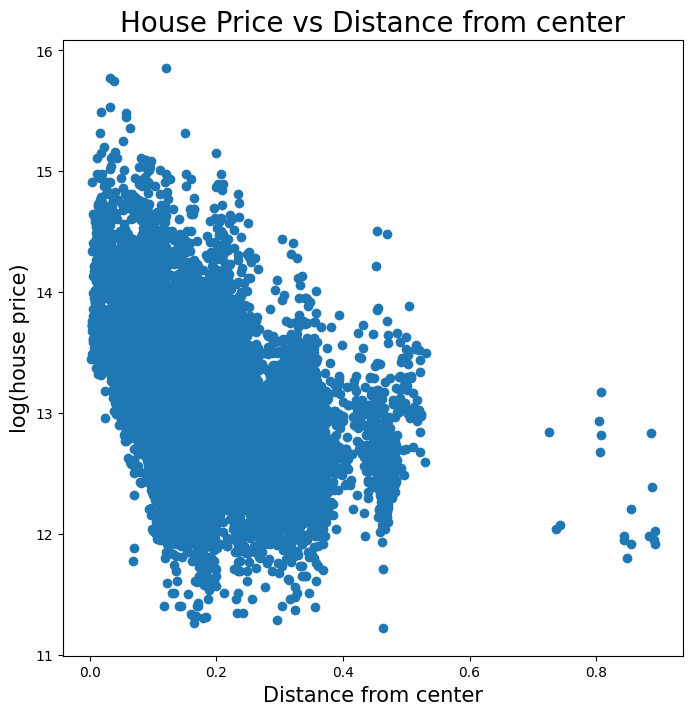

In [ ]:
# Distance from high priced houses center to every house using Euclidean distance formula
# have added new feature 'High_cen_distance' to the dataset
house_price_data["High_cen_distance"]=np.sqrt((house_price_data["long"] - high_long_mean) ** 2 + (house_price_data["lat"] - high_lat_mean) ** 2)

plt.figure(figsize=(8,8))
plt.scatter(house_price_data["High_cen_distance"],np.log(house_price_data["price"]))  # using log(price) makes Variance becomes more uniform
plt.title('House Price vs Distance from center', fontsize=20)
plt.xlabel('Distance from center', fontsize=15)
plt.ylabel('log(house price)', fontsize=15)

# graph represents that as the distance from high priced houses center increases, the house price decreases (-ve slope)

### Model3 With Geo variable treatment

In [ ]:
#Defining X data
col_names = house_price_data.columns.values
# print(col_names)

x_col_names=col_names[3:]
print(x_col_names)

X = house_price_data[x_col_names]
y = house_price_data['price']

from sklearn  import model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y ,test_size=0.2, random_state=55)

print(X_train.shape)   # 'High_cen_distance' feature has been added
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

import sklearn
model3 = sklearn.linear_model.LinearRegression()
model3.fit(X_train, y_train)

<StringArray>
[         'bedrooms',         'bathrooms',       'sqft_living',
          'sqft_lot',            'floors',        'waterfront',
              'view',         'condition',             'grade',
        'sqft_above',     'sqft_basement',          'yr_built',
      'yr_renovated',           'zipcode',               'lat',
              'long',     'sqft_living15',        'sqft_lot15',
 'High_cen_distance']
Length: 19, dtype: str
(17290, 19)
(17290,)
(4323, 19)
(4323,)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Rsquared Calculation on Train data
from sklearn import metrics
y_pred_train=model3.predict(X_train)
print("Train data R-Squared : ", metrics.r2_score(y_train,y_pred_train))

# Rsquared Calculation on test data
y_pred_test=model3.predict(X_test)
print("Test data R-Squared : " , metrics.r2_score(y_test,y_pred_test))
# MAPE
print("MAPE on Train data : ", round(np.mean(np.abs(y_train - y_pred_train)/y_train),2))
print("MAPE on Test data : ", round(np.mean(np.abs(y_test - y_pred_test)/y_test),2))

# Accuracy has improved after adding the new feature 'High_cen_distance'

Train data R-Squared :  0.7148088489464612
Test data R-Squared :  0.7090610925034689
MAPE on Train data :  0.26
MAPE on Test data :  0.26


## Transformers